In [1]:
import numpy as np


def f(x):
    return x[0]**2 + 10 * x[1]**2


def gradient(x):
    return np.array([2 * x[0], 20 * x[1]], dtype=float)


def hessian(x):
    return np.array([[2.0, 0.0], [0.0, 20.0]])


def backtracking_line_search(x, d, grad, alpha=1.0, beta=0.5, c=1e-4):
    while f(x + alpha * d) > f(x) + c * alpha * np.dot(grad, d):
        alpha *= beta
    return alpha


def gradient_descent(x_0=np.array([3.0, 2.0]), max_iter=100, tol=1e-6):
    x = np.array(x_0, dtype=float, copy=True)
    path = [x.copy()]

    for k in range(max_iter):
        grad = gradient(x)
        if np.linalg.norm(grad) < tol:
            return x, f(x), k, np.array(path)

        d = -grad
        alpha = backtracking_line_search(x, d, grad)
        x = x + alpha * d
        path.append(x.copy())

    return x, f(x), max_iter, np.array(path)


def newton(x_0=np.array([3.0, 2.0]), max_iter=100, tol=1e-6):
    x = np.array(x_0, dtype=float, copy=True)
    path = [x.copy()]

    for k in range(max_iter):
        grad = gradient(x)
        if np.linalg.norm(grad) < tol:
            return x, f(x), k, np.array(path)

        d = np.linalg.solve(hessian(x), -grad)
        x = x + d
        path.append(x.copy())

    return x, f(x), max_iter, np.array(path)


def BFGS(x_0=np.array([3.0, 2.0]), max_iter=100, tol=1e-6):
    x = np.array(x_0, dtype=float, copy=True)
    B = np.eye(len(x))  # ヘッセ行列の近似
    path = [x.copy()]

    for k in range(max_iter):
        grad = gradient(x)
        if np.linalg.norm(grad) < tol:
            return x, f(x), k, np.array(path)

        d = np.linalg.solve(B, -grad)
        alpha = backtracking_line_search(x, d, grad)
        s_k = (alpha * d).reshape(-1, 1)
        x_new = x + s_k.ravel()
        y_k = (gradient(x_new) - grad).reshape(-1, 1)

        sBs = (s_k.T @ B @ s_k).item()
        ys = (y_k.T @ s_k).item()
        if sBs > 1e-12 and ys > 1e-12:
            B = B - (B @ s_k @ s_k.T @ B) / sBs + (y_k @ y_k.T) / ys

        x = x_new
        path.append(x.copy())

    return x, f(x), max_iter, np.array(path)


--- 最急降下法 ---
最終解: [ 3.41261954e-07 -3.26993573e-08]
目的関数値: 1.2715220095e-13
反復回数: 63
最終勾配ノルム: 9.4527142819e-07


C:\Users\hanha\AppData\Local\Temp\ipykernel_3860\2915068022.py:36: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hanha\AppData\Local\Temp\ipykernel_3860\2915068022.py:36: UserWarning: Glyph 24613 (\N{CJK UNIFIED IDEOGRAPH-6025}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hanha\AppData\Local\Temp\ipykernel_3860\2915068022.py:36: UserWarning: Glyph 38477 (\N{CJK UNIFIED IDEOGRAPH-964D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hanha\AppData\Local\Temp\ipykernel_3860\2915068022.py:36: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hanha\AppData\Local\Temp\ipykernel_3860\2915068022.py:36: UserWarning: Glyph 27861 (\N{CJK UNIFIED IDEOGRAPH-6CD5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hanha\AppData\Local\Temp\ipykernel_3860\2915068022.py:36: UserWarning: Glyph 12398 (\N{HIRA

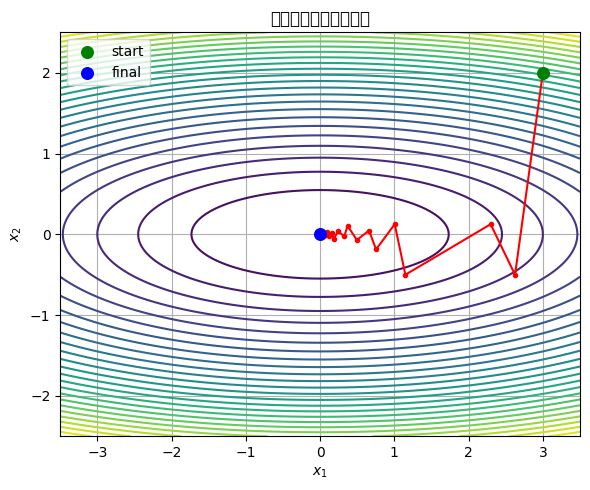

--- Newton法 ---
最終解: [0. 0.]
目的関数値: 0.0000000000e+00
反復回数: 1
最終勾配ノルム: 0.0000000000e+00


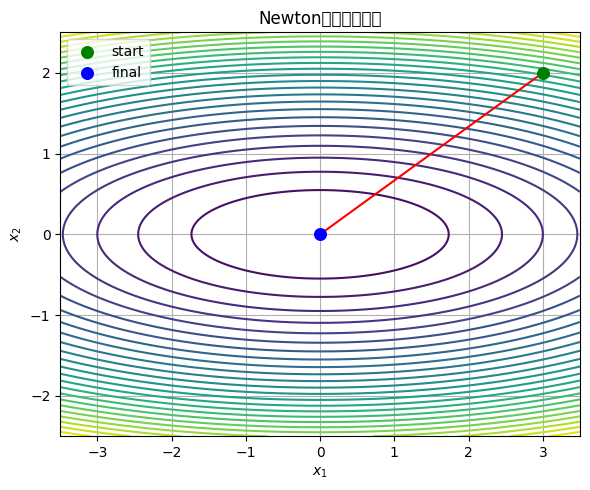

--- BFGS法 ---
最終解: [ 1.17808182e-08 -1.10472063e-10]
目的関数値: 1.3890971889e-16
反復回数: 6
最終勾配ノルム: 2.3665002496e-08


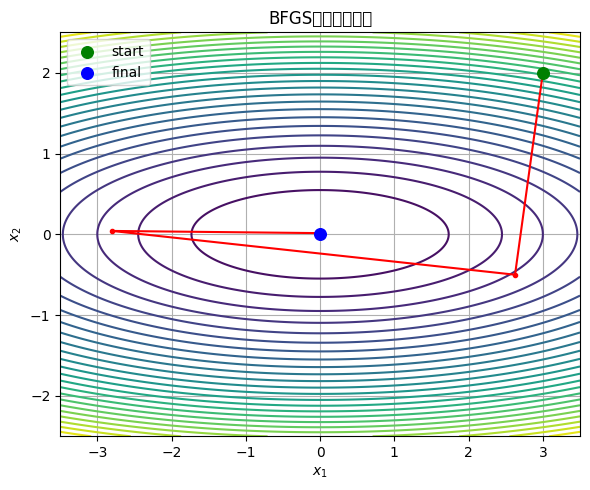

In [2]:
# 実行コード
import matplotlib.pyplot as plt

x_0 = np.array([3.0, 2.0])
methods = {
    '最急降下法': gradient_descent,
    'Newton法': newton,
    'BFGS法': BFGS,
}

x1 = np.linspace(-3.5, 3.5, 400)
x2 = np.linspace(-2.5, 2.5, 400)
X1, X2 = np.meshgrid(x1, x2)
Z = X1**2 + 10 * X2**2

for name, method in methods.items():
    x_final, f_final, iterations, path = method(x_0)
    grad_norm = np.linalg.norm(gradient(x_final))

    print(f'--- {name} ---')
    print(f'最終解: {x_final}')
    print(f'目的関数値: {f_final:.10e}')
    print(f'反復回数: {iterations}')
    print(f'最終勾配ノルム: {grad_norm:.10e}')

    plt.figure(figsize=(6, 5))
    plt.contour(X1, X2, Z, levels=25)
    plt.plot(path[:, 0], path[:, 1], 'o-', color='red', markersize=3)
    plt.scatter(path[0, 0], path[0, 1], color='green', s=70, label='start', zorder=3)
    plt.scatter(path[-1, 0], path[-1, 1], color='blue', s=70, label='final', zorder=3)
    plt.title(f'{name}の収束経路')
    plt.xlabel('$x_1$')
    plt.ylabel('$x_2$')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## 課題２


===== Initial point: (-4, 4) =====
[Gradient descent]
  Final point: [ 3.58442833 -1.84812653]
  Objective value: 3.3467813814e-15
  Iterations: 40
  Final gradient norm: 8.4001653833e-07
[Newton]
  Final point: [-2.80511809  3.13131252]
  Objective value: 1.3373083401e-22
  Iterations: 5
  Final gradient norm: 1.3169999486e-10
[BFGS]
  Final point: [ 3.58442834 -1.84812653]
  Objective value: 8.4080770191e-21
  Iterations: 12
  Final gradient norm: 1.3277130374e-09


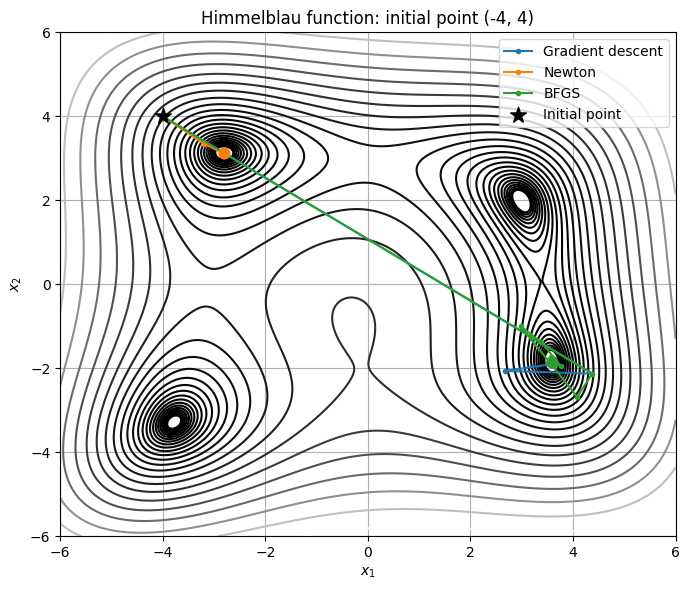


===== Initial point: (-3, -3) =====
[Gradient descent]
  Final point: [-3.77931025 -3.28318599]
  Objective value: 4.2731108246e-17
  Iterations: 14
  Final gradient norm: 1.0084476125e-07
[Newton]
  Final point: [-3.77931025 -3.28318599]
  Objective value: 3.3408182343e-22
  Iterations: 5
  Final gradient norm: 2.6363560710e-10
[BFGS]
  Final point: [-3.77931025 -3.28318599]
  Objective value: 4.8332552061e-19
  Iterations: 9
  Final gradient norm: 8.2739119141e-09


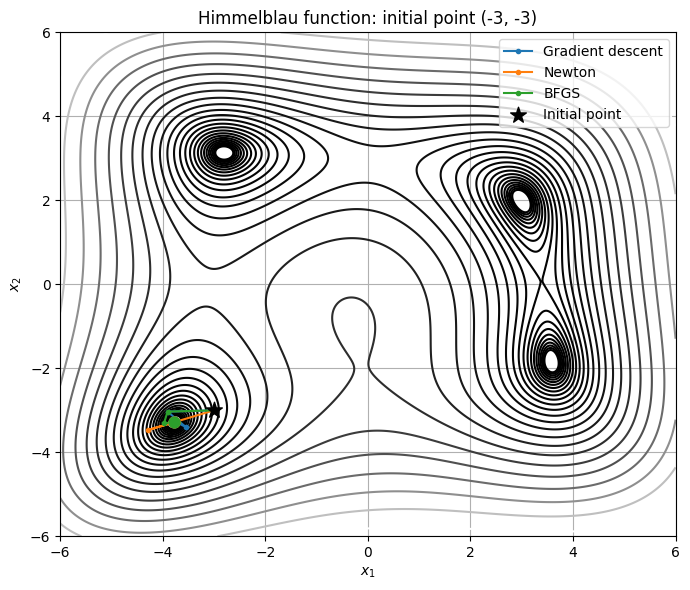


===== Initial point: (0, 0) =====
[Gradient descent]
  Final point: [3. 2.]
  Objective value: 8.1902763580e-16
  Iterations: 25
  Final gradient norm: 3.4025864665e-07
[Newton]
  Final point: [-0.27084459 -0.92303856]
  Objective value: 1.8161652152e+02
  Iterations: 4
  Final gradient norm: 1.2433510999e-09
[BFGS]
  Final point: [3. 2.]
  Objective value: 1.4283529106e-19
  Iterations: 10
  Final gradient norm: 3.7924768241e-09


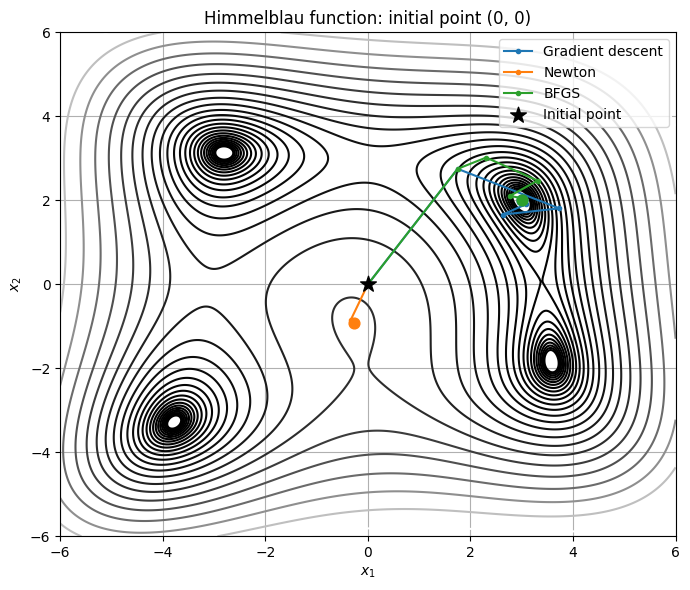


===== Initial point: (3, 3) =====
[Gradient descent]
  Final point: [2.99999999 2.00000001]
  Objective value: 4.9070372104e-15
  Iterations: 21
  Final gradient norm: 6.6709564786e-07
[Newton]
  Final point: [3. 2.]
  Objective value: 1.1164782589e-19
  Iterations: 5
  Final gradient norm: 2.6258677075e-09
[BFGS]
  Final point: [3. 2.]
  Objective value: 5.5423532796e-18
  Iterations: 8
  Final gradient norm: 1.9590968024e-08


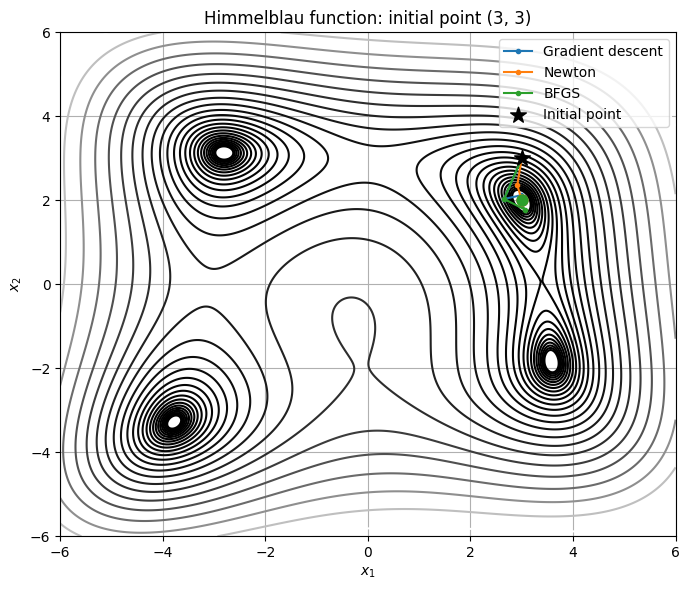


===== Initial point: (5, -2) =====
[Gradient descent]
  Final point: [-3.77931025 -3.28318599]
  Objective value: 3.7073987628e-16
  Iterations: 13
  Final gradient norm: 2.4359416356e-07
[Newton]
  Final point: [ 3.58442834 -1.84812653]
  Objective value: 5.1356012444e-24
  Iterations: 5
  Final gradient norm: 3.2638558446e-11
[BFGS]
  Final point: [-3.77931025 -3.28318598]
  Objective value: 3.5197707153e-15
  Iterations: 11
  Final gradient norm: 8.5547867939e-07


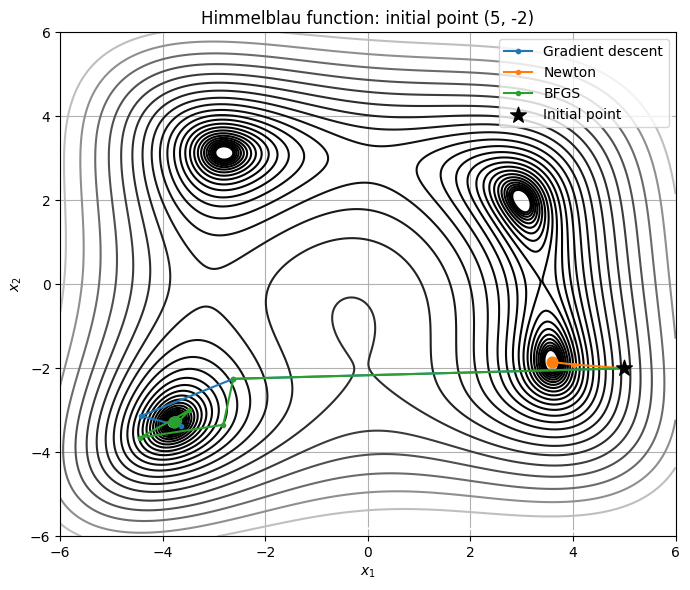

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def hb(x):
    first = (x[0]**2 + x[1] -11)**2
    second = (x[0] + x[1]**2 -7)**2

    return first + second

# Himmelblau関数の勾配とヘッセ行列
def hb_gradient(x):
    a = x[0]**2 + x[1] - 11
    b = x[0] + x[1]**2 - 7
    return np.array([4 * x[0] * a + 2 * b, 2 * a + 4 * x[1] * b])

def hb_hessian(x):
    return np.array([
        [12 * x[0]**2 + 4 * x[1] - 42, 4 * (x[0] + x[1])],
        [4 * (x[0] + x[1]), 4 * x[0] + 12 * x[1]**2 - 26]
    ])

def hb_line_search(x, d, grad, alpha=1.0, beta=0.5, c=1e-4):
    while hb(x + alpha * d) > hb(x) + c * alpha * np.dot(grad, d):
        alpha *= beta
    return alpha

def hb_gradient_descent(x_0, max_iter=100, tol=1e-6):
    x = np.array(x_0, dtype=float, copy=True)
    path = [x.copy()]
    for k in range(max_iter):
        grad = hb_gradient(x)
        if np.linalg.norm(grad) < tol:
            return x, hb(x), k, np.array(path)
        d = -grad
        alpha = hb_line_search(x, d, grad)
        x = x + alpha * d
        path.append(x.copy())
    return x, hb(x), max_iter, np.array(path)

def hb_newton(x_0, max_iter=100, tol=1e-6):
    x = np.array(x_0, dtype=float, copy=True)
    path = [x.copy()]
    for k in range(max_iter):
        grad = hb_gradient(x)
        if np.linalg.norm(grad) < tol:
            return x, hb(x), k, np.array(path)
        d = np.linalg.solve(hb_hessian(x), -grad)
        x = x + d
        path.append(x.copy())
    return x, hb(x), max_iter, np.array(path)

def hb_BFGS(x_0, max_iter=100, tol=1e-6):
    x = np.array(x_0, dtype=float, copy=True)
    B = np.eye(len(x))
    path = [x.copy()]
    for k in range(max_iter):
        grad = hb_gradient(x)
        if np.linalg.norm(grad) < tol:
            return x, hb(x), k, np.array(path)
        d = np.linalg.solve(B, -grad)
        alpha = hb_line_search(x, d, grad)
        s_k = (alpha * d).reshape(-1, 1)
        x_new = x + s_k.ravel()
        y_k = (hb_gradient(x_new) - grad).reshape(-1, 1)
        sBs = (s_k.T @ B @ s_k).item()
        ys = (y_k.T @ s_k).item()
        if sBs > 1e-12 and ys > 1e-12:
            B = B - (B @ s_k @ s_k.T @ B) / sBs + (y_k @ y_k.T) / ys
        x = x_new
        path.append(x.copy())
    return x, hb(x), max_iter, np.array(path)

# 初期値ごとに3手法を比較（経路図は5枚）
initial_points = [(-4, 4), (-3, -3), (0, 0), (3, 3), (5, -2)]
hb_methods = {
    'Gradient descent': hb_gradient_descent,
    'Newton': hb_newton,
    'BFGS': hb_BFGS
}

x1 = np.linspace(-6, 6, 500)
x2 = np.linspace(-6, 6, 500)
X1, X2 = np.meshgrid(x1, x2)
Z = (X1**2 + X2 - 11)**2 + (X1 + X2**2 - 7)**2

for point in initial_points:
    x_0 = np.array(point, dtype=float)
    plt.figure(figsize=(7, 6))
    plt.contour(X1, X2, Z, levels=np.logspace(0, 3, 25), cmap='gray')
    print(f'\n===== Initial point: {point} =====')

    for name, method in hb_methods.items():
        x_final, hb_final, iterations, path = method(x_0)
        grad_norm = np.linalg.norm(hb_gradient(x_final))
        print(f'[{name}]')
        print(f'  Final point: {x_final}')
        print(f'  Objective value: {hb_final:.10e}')
        print(f'  Iterations: {iterations}')
        print(f'  Final gradient norm: {grad_norm:.10e}')
        plt.plot(path[:, 0], path[:, 1], 'o-', markersize=3, label=name)
        plt.scatter(path[-1, 0], path[-1, 1], s=60, zorder=3)

    plt.scatter(x_0[0], x_0[1], color='black', marker='*', s=140,
                label='Initial point', zorder=4)
    plt.title(f'Himmelblau function: initial point {point}')
    plt.xlabel('$x_1$')
    plt.ylabel('$x_2$')
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [4]:
# 課題3：KKT条件を有効制約集合で実装
import numpy as np

def kkt_objective(x, center):
    return np.sum((x - center)**2)

def g(x):
    return np.array([x[0]**2 + x[1]**2 - 1, -x[0], -x[1]])

def grad_g(x):
    return [np.array([2*x[0], 2*x[1]]),
            np.array([-1.0, 0.0]), np.array([0.0, -1.0])]

def solve_active_set(center, active_set, max_iter=100, tol=1e-10):
    center = np.array(center, dtype=float)
    active_set = list(active_set)
    m = len(active_set)
    x = center.copy()

    if 0 in active_set:
        x = center / np.linalg.norm(center)
    if 1 in active_set:
        x[0] = 0.0
    if 2 in active_set:
        x[1] = 0.0
    if 0 in active_set and 1 in active_set:
        x = np.array([0.0, 1.0 if center[1] >= 0 else -1.0])
    if 0 in active_set and 2 in active_set:
        x = np.array([1.0 if center[0] >= 0 else -1.0, 0.0])

    z = np.r_[x, np.zeros(m)]
    for iteration in range(max_iter):
        x, mu = z[:2], z[2:]
        gradients = grad_g(x)
        stationarity = 2*(x - center)
        for j, i in enumerate(active_set):
            stationarity += mu[j]*gradients[i]
        F = np.r_[stationarity, g(x)[active_set]]
        if np.linalg.norm(F) < tol:
            mu_all = np.zeros(3)
            mu_all[active_set] = mu
            return x, mu_all, iteration

        H = 2*np.eye(2)
        if 0 in active_set:
            H += 2*mu[active_set.index(0)]*np.eye(2)
        G = np.column_stack([gradients[i] for i in active_set]) if m else np.empty((2, 0))
        J = np.block([[H, G], [G.T, np.zeros((m, m))]])
        try:
            z += np.linalg.solve(J, -F)
        except np.linalg.LinAlgError:
            return None
    return None

def verify_kkt(center, active_set, result, tol=1e-7):
    x, mu, _ = result
    gx = g(x)
    stationarity = 2*(x - np.array(center, dtype=float))
    for i in range(3):
        stationarity += mu[i]*grad_g(x)[i]
    return (np.all(gx <= tol) and
            all(abs(gx[i]) <= tol for i in active_set) and
            all(gx[i] < -tol for i in range(3) if i not in active_set) and
            np.all(mu >= -tol) and
            np.all(np.abs(mu*gx) <= tol) and
            np.linalg.norm(stationarity) <= tol)

active_sets = [(), (0,), (1,), (2,), (0, 1), (0, 2), (1, 2)]
centers = [(2, 1), (-1, 1), (1, -1), (-1, -1)]
names = ['g1', 'g2', 'g3']

for center in centers:
    candidates = []
    print(f'\n===== center = {center} =====')
    for A in active_sets:
        result = solve_active_set(center, A)
        label = '{' + ', '.join(names[i] for i in A) + '}'
        valid = result is not None and verify_kkt(center, A, result)
        print(f'A = {label:8s}: ' + ('KKT OK' if valid else '不適合'))
        if valid:
            x, mu, iteration = result
            candidates.append((kkt_objective(x, np.array(center)), x, mu, A))

    value, x_star, mu_star, A_star = min(candidates, key=lambda item: item[0])
    print(f'最適解 x* = {x_star}')
    print(f'f(x*) = {value:.10f}')
    print(f'active set = {[names[i] for i in A_star]}')
    print(f'mu = {mu_star}')



===== center = (2, 1) =====
A = {}      : 不適合
A = {g1}    : KKT OK
A = {g2}    : 不適合
A = {g3}    : 不適合
A = {g1, g2}: 不適合
A = {g1, g3}: 不適合
A = {g2, g3}: 不適合
最適解 x* = [0.89442719 0.4472136 ]
f(x*) = 1.5278640450
active set = ['g1']
mu = [1.23606798 0.         0.        ]

===== center = (-1, 1) =====
A = {}      : 不適合
A = {g1}    : 不適合
A = {g2}    : 不適合
A = {g3}    : 不適合
A = {g1, g2}: KKT OK
A = {g1, g3}: 不適合
A = {g2, g3}: 不適合
最適解 x* = [0. 1.]
f(x*) = 1.0000000000
active set = ['g1', 'g2']
mu = [0. 2. 0.]

===== center = (1, -1) =====
A = {}      : 不適合
A = {g1}    : 不適合
A = {g2}    : 不適合
A = {g3}    : 不適合
A = {g1, g2}: 不適合
A = {g1, g3}: KKT OK
A = {g2, g3}: 不適合
最適解 x* = [1. 0.]
f(x*) = 1.0000000000
active set = ['g1', 'g3']
mu = [0. 0. 2.]

===== center = (-1, -1) =====
A = {}      : 不適合
A = {g1}    : 不適合
A = {g2}    : 不適合
A = {g3}    : 不適合
A = {g1, g2}: 不適合
A = {g1, g3}: 不適合
A = {g2, g3}: KKT OK
最適解 x* = [0. 0.]
f(x*) = 2.0000000000
active set = ['g2', 'g3']
mu = [0. 2. 2.]
